<a href="https://colab.research.google.com/github/Ali13fffff/hotel-booking-cancellation-analysis/blob/main/hotel_booking_cancellation_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from google.colab import files
uploaded = files.upload()

Saving booking.csv to booking (1).csv


#Import libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Data

In [17]:
df=pd.read_csv("booking.csv")
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

#Cleaning Data

In [18]:
print(df.isnull().sum())
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df["Booking_ID"].is_unique)
df=df.drop(columns=["Booking_ID"])

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64
0
True


#Creating a new feature for analyzing the target column

In [19]:


status_mapping = {
    "Canceled": 1,
    "Not_Canceled": 0,
}

df = df.copy()

df["total_nights"] = (
    df["number of weekend nights"].fillna(0)
    + df["number of week nights"].fillna(0)
)

#total_revenue represents estimated potential revenue, not actual realized revenue.
df["total_revenue"] = (
    df["total_nights"]
    * df["average price"].fillna(0)
)

df["booking_status_number"] = df["booking status"].map(status_mapping)

#Analysis of Booking Status

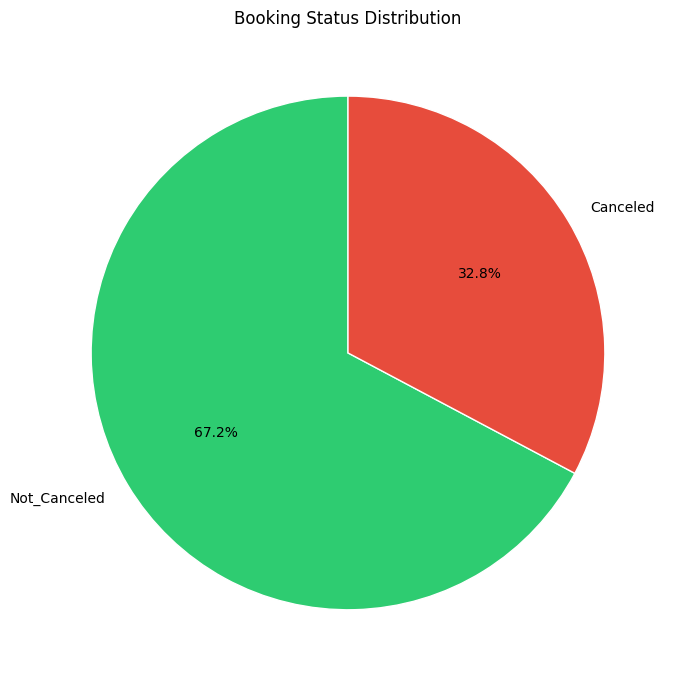

In [20]:

booking_status = (
    df["booking status"]
    .value_counts()
    .reindex(["Not_Canceled", "Canceled"])
)




plt.figure(figsize=(7, 7))
plt.pie(
    booking_status.values,
    labels=booking_status.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2ecc71", "#e74c3c"],
    wedgeprops={"edgecolor": "white", "linewidth": 1},
)
plt.title("Booking Status Distribution")
plt.tight_layout()
plt.show()

#The dataset is moderately imbalanced toward non-canceled bookings, with approximately two-thirds of bookings not canceled and one-third canceled.
Further analysis can examine variables such as lead time, length of stay, room type, market segment type, and booking-related characteristics.

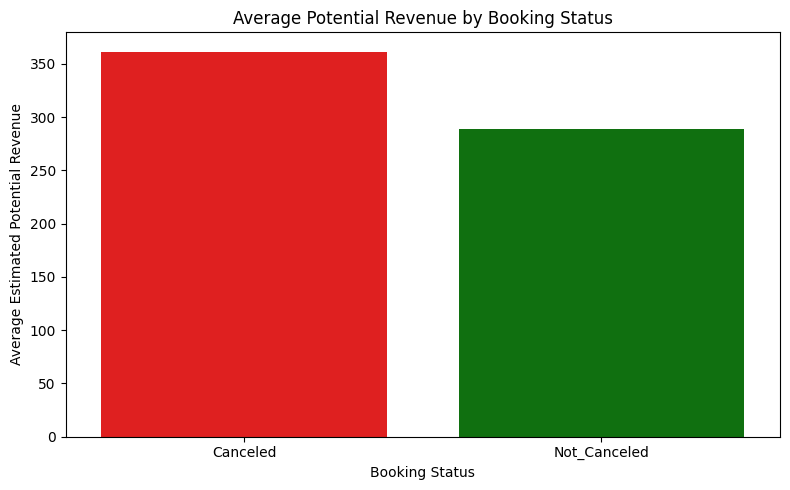

In [21]:
average_revenue_by_status = (
    df.groupby("booking status")["total_revenue"]
    .mean()
    .reset_index(name="average_potential_revenue")
)

status_palette = {
    "Not_Canceled": "green",
    "Canceled": "red",
}

plt.figure(figsize=(8, 5))

sns.barplot(
    data=average_revenue_by_status,
    x="booking status",
    y="average_potential_revenue",
    hue="booking status",
    palette=status_palette,
    legend=False
)

plt.title("Average Potential Revenue by Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Average Estimated Potential Revenue")
plt.tight_layout()
plt.show()

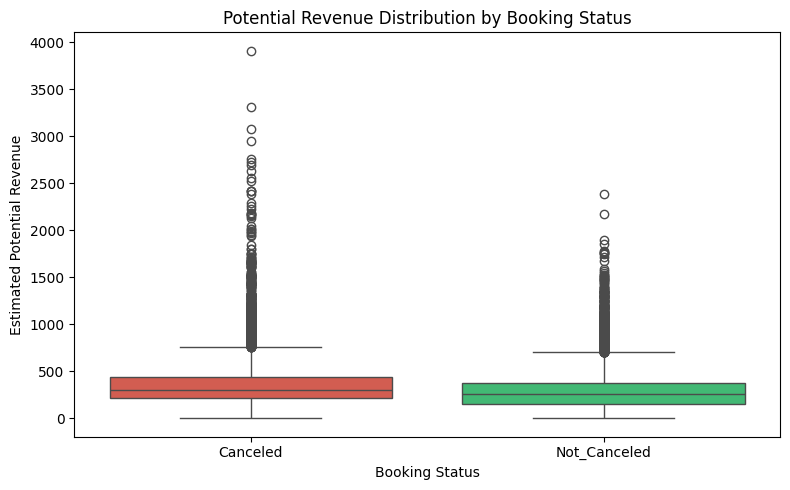

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="booking status",
    y="total_revenue",
    hue="booking status",
    order=["Canceled", "Not_Canceled"],
    hue_order=["Canceled", "Not_Canceled"],
    palette={
        "Canceled": "#e74c3c",
        "Not_Canceled": "#2ecc71"
    },
    legend=False
)
plt.title("Potential Revenue Distribution by Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Estimated Potential Revenue")
plt.tight_layout()
plt.show()

#The boxplot shows that canceled bookings have more outliers than non-canceled bookings, indicating greater variability in potential revenue. However, the medians of the two groups are relatively similar. Therefore, the main difference between the groups is related to the outliers rather than their typical revenue values.

#Key Business Insight:
Although most bookings are confirmed, canceled reservations still represent a significant potential revenue loss for the hotel. The average potential revenue of canceled bookings is notably higher than that of non-canceled bookings, suggesting that high-value reservations may be at greater risk of cancellation.

#Categorical Features Analysis

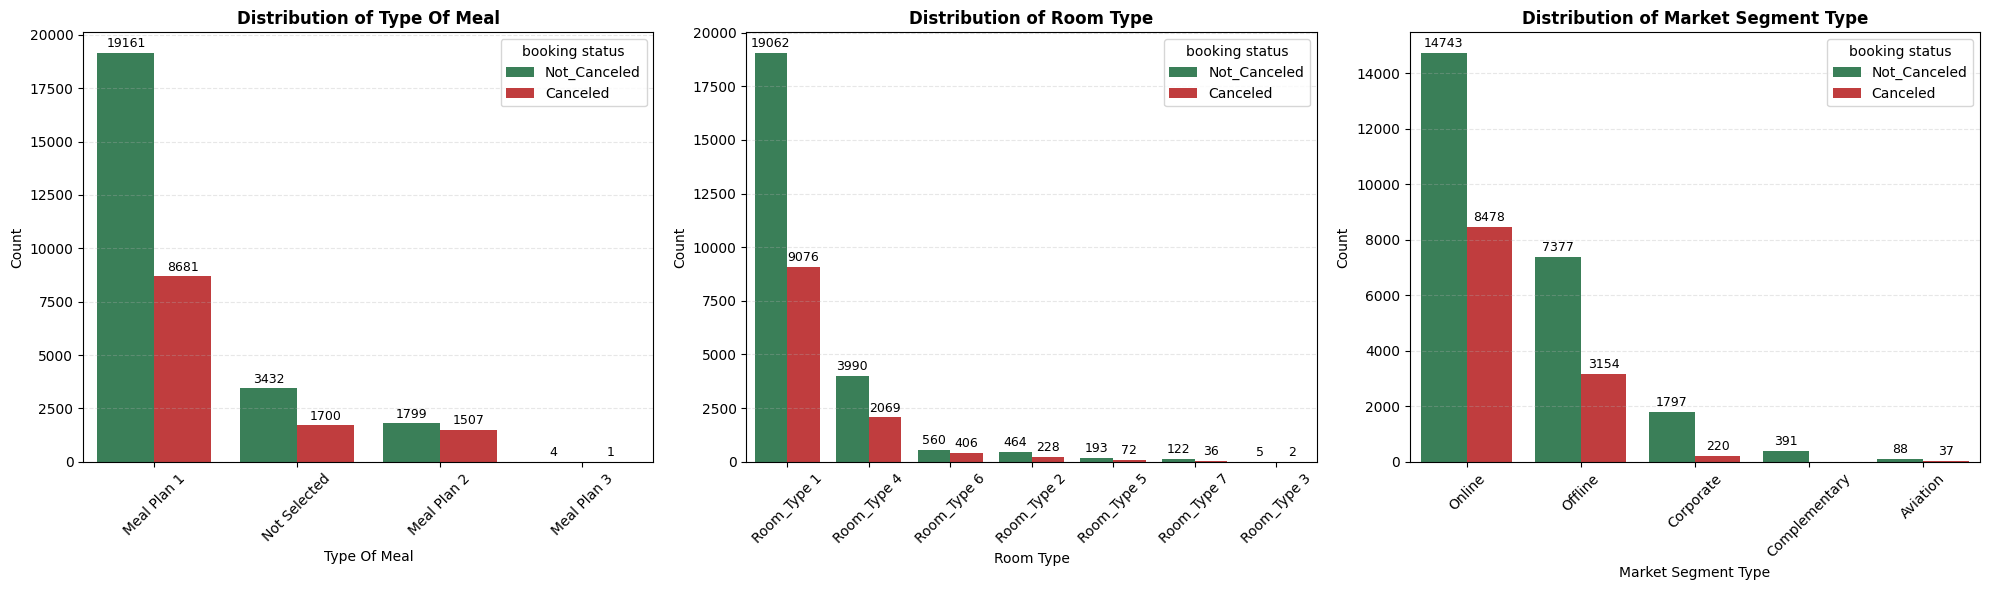

In [ ]:

categorical_features = [
    "type of meal",
    "room type",
    "market segment type"
]

palette = {"Not_Canceled": "#2E8B57", "Canceled": "#D62728"}


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6), sharey=False)

for i, col in enumerate(categorical_features):
    ax = axes[i]


    sns.countplot(
        data=df,
        x=col,
        hue="booking status",
        palette=palette,
        ax=ax,
        order=df[col].value_counts().index # مرتب‌سازی از بیشترین به کمترین
    )

    ax.set_title(f"Distribution of {col.title()}", fontsize=12, fontweight="bold")
    ax.set_xlabel(col.title(), fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", alpha=0.3)


    for container in ax.containers:
        ax.bar_label(container, fontsize=9, padding=2)

plt.tight_layout()
plt.show()

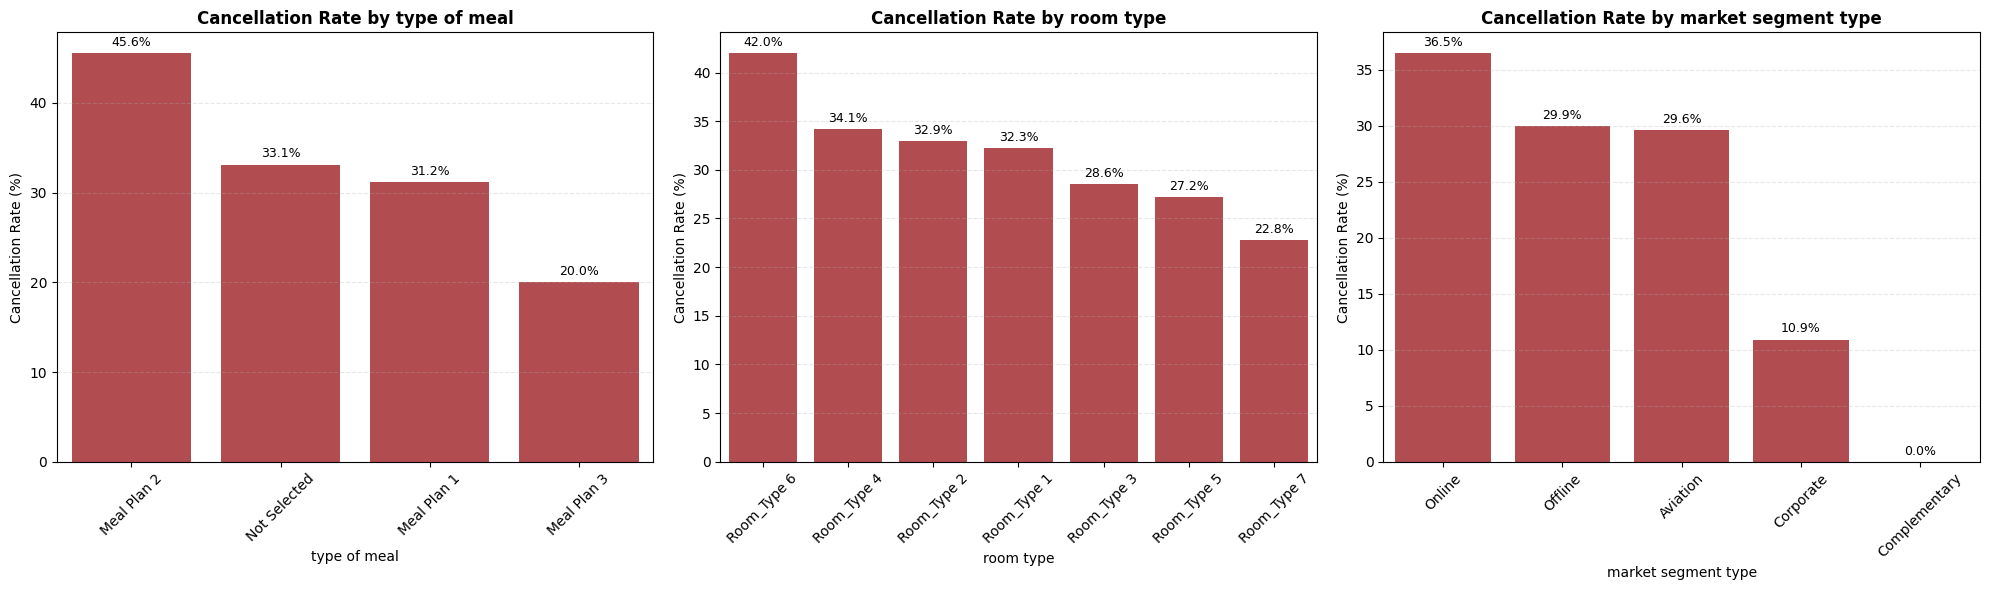

In [ ]:


fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(20, 6)
)

for i, col in enumerate(categorical_features):
    ax = axes[i]


    cancellation_rate = (
        df.groupby(col)["booking_status_number"]
          .mean()
          .sort_values(ascending=False)
          .reset_index()
    )

    cancellation_rate["booking_status_number"] *= 100

    sns.barplot(
        data=cancellation_rate,
        x=col,
        y="booking_status_number",
        color="#C23B40",
        ax=ax
    )

    ax.set_title(
        f"Cancellation Rate by {col}",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel(col)
    ax.set_ylabel("Cancellation Rate (%)")

    ax.tick_params(
        axis="x",
        rotation=45
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )


    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3,
            fontsize=9
        )

plt.tight_layout()
plt.show()

#Categorical Feature Analysis:

The analysis shows that Meal Plan 1, Room Type 1, and the Online market segment have the highest number of bookings in their respective categories. This indicates that these are the most common meal plan, room type, and booking channel in the dataset.

Regarding cancellation rates, Meal Plan 2 has the highest cancellation rate among the meal plan categories. Room Type 6 shows the highest cancellation rate among the room types, while the Online market segment has the highest cancellation rate among the major market segments.

Some categories, such as Meal Plan 3, Room Type 3, and Aviation, contain relatively few bookings. Therefore, their cancellation rates should be interpreted cautiously because small sample sizes can produce unstable results.
These findings provide useful initial insights into booking behavior and cancellation risk.
 However, cancellation rates should be interpreted together with booking volume and sample size. Further analysis of numerical variables such as lead time, total nights, average price, and special requests may help identify the strongest factors associated with cancellations.

#Converting the date attribute to the appropriate format

In [ ]:


df['date of reservation'] = pd.to_datetime(df['date of reservation'], errors='coerce')

#Monthly Booking Volume and Cancellation Patterns Across All Years

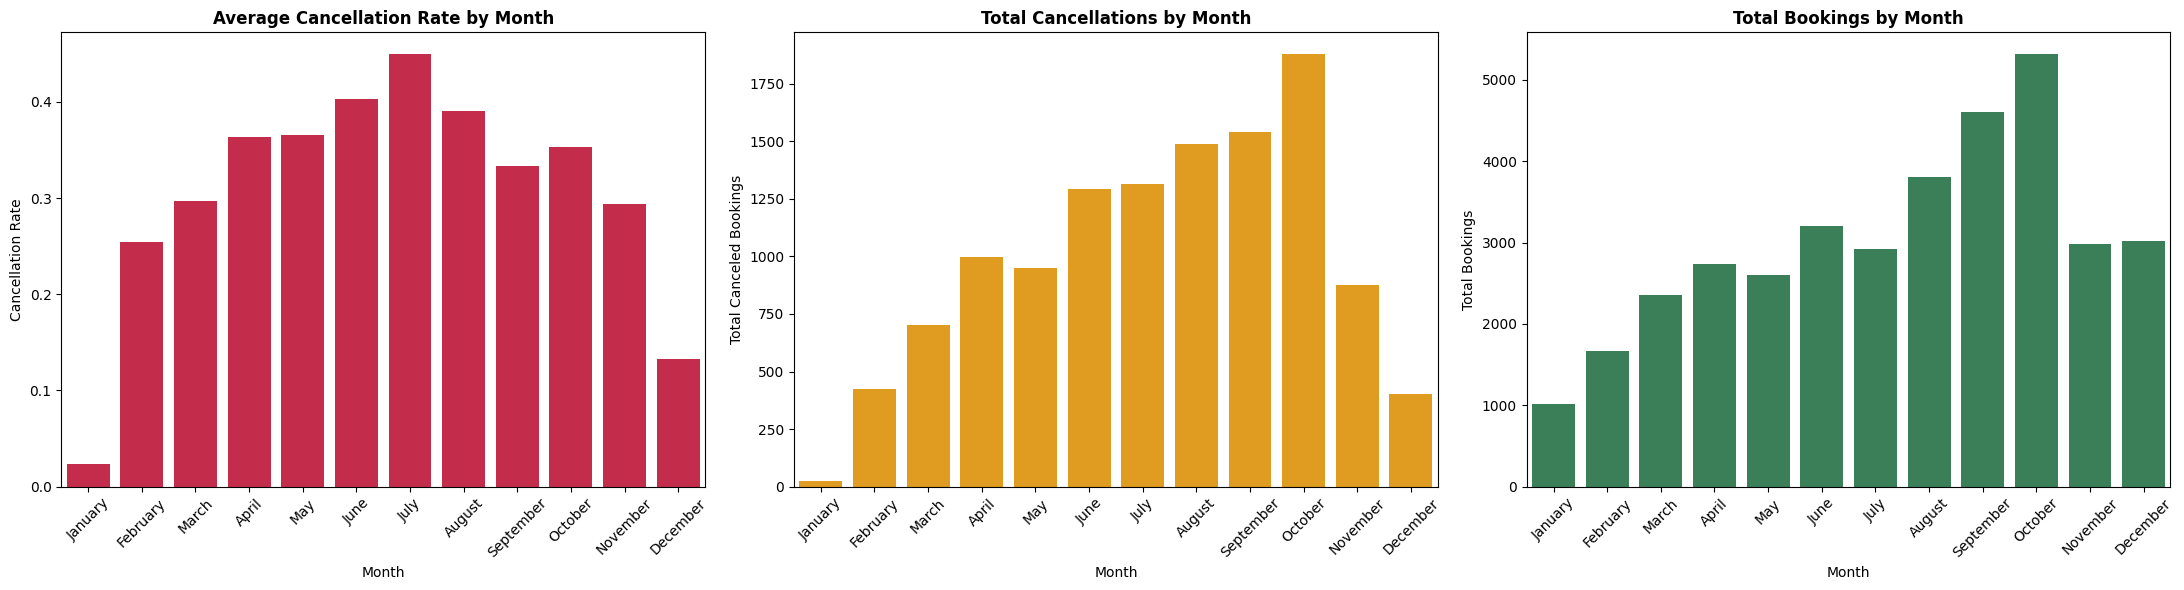

In [ ]:

df["month_num"] = df["date of reservation"].dt.month
df["month_name"] = df["date of reservation"].dt.month_name()


monthly_summary = (
    df.groupby(["month_num", "month_name"])
    .agg(
        cancellation_rate=("booking_status_number", "mean"),
        total_cancellations=("booking_status_number", "sum"),
        total_bookings=("booking_status_number", "size")
    )
    .reset_index()
    .sort_values("month_num")
)


fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(
    data=monthly_summary,
    x="month_name",
    y="cancellation_rate",
    ax=axes[0],
    color="crimson"
)

sns.barplot(
    data=monthly_summary,
    x="month_name",
    y="total_cancellations",
    ax=axes[1],
    color="orange"
)

sns.barplot(
    data=monthly_summary,
    x="month_name",
    y="total_bookings",
    ax=axes[2],
    color="seagreen"
)

titles = [
    "Average Cancellation Rate by Month",
    "Total Cancellations by Month",
    "Total Bookings by Month"
]

for ax, title in zip(axes, titles):
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Month")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Cancellation Rate")
axes[1].set_ylabel("Total Canceled Bookings")
axes[2].set_ylabel("Total Bookings")

plt.tight_layout()
plt.show()

#August, September, and October have the highest booking volumes and therefore also account for the highest numbers of cancellations. July has the highest cancellation rate relative to its total number of bookings, indicating a higher cancellation risk in proportion to booking volume. These results are based on the reservation date and should not be interpreted as definitive evidence of the hotel's tourist season.